In [1]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import nibabel as nib
import pandas as pd
class TransBTS_model_dataset(Dataset):
    def __init__(self, BrainMRIFilesPath, CSVPath, transform=None):        
        self.BrainMRIFilesPath = BrainMRIFilesPath
        self.CSVPath = CSVPath
        self.transform = transform
        self.df = pd.read_excel(self.CSVPath , engine='openpyxl')
        
        self.Files = os.listdir(self.BrainMRIFilesPath)

        self.ID_To_Filename = {}
        self.IDs = []
        for file in self.Files:
            strc = file.split('-')
            self.ID_To_Filename[int(strc[0][-3:])] = file
            self.IDs.append(int(strc[0][-3:]))

    def __len__(self):
        return len(self.IDs)

    def __getitem__(self, index):
        ID = self.IDs[index]
        filename = self.ID_To_Filename[ID]
        file_path = os.path.join(self.BrainMRIFilesPath ,filename)
        if self.transform is not None:
            image = transforms(file_path)              # returns torch.Tensor
            array = image.numpy()[0]                    
        
        age = self.df[self.df['IXI_ID'] == ID]['AGE'].values[0]
        return array, age
        

In [51]:
AllAgesData = []
for i in range(len(ds)):
    
    ImageVolume, age = ds[i]
    AllAgesData.append(age)
    

In [52]:
AllAgesData

[58.65845311430527,
 26.272416153319643,
 37.765913757700204,
 27.014373716632445,
 39.397672826830934,
 48.05201916495551,
 67.53456536618754,
 25.713894592744694,
 27.381245722108144,
 73.56331279945243,
 67.77275838466804,
 60.91991786447639,
 73.54414784394251,
 59.742642026009584,
 55.540041067761805,
 28.347707049965777,
 46.42573579739904]

In [2]:
from monai.transforms import LoadImage, Compose, Spacing, Resize, EnsureChannelFirst, ScaleIntensity
import numpy as np
transforms = Compose([
    LoadImage(image_only=True),
    EnsureChannelFirst(),                   # shape: (1, H, W, D)
    ScaleIntensity(),                       # optional: normalize to 0-1
    Spacing(pixdim=(1.0, 1.0, 1.0), mode="bilinear"),  # resample to 1mm spacing
    Resize(spatial_size=(128, 128, 128), mode='trilinear')  # resize to 128³
])

In [10]:
BrainMRIFilesPath = r"C:\Users\Rishabh\Documents\PreprocessedData1mm"
CSVPath = os.path.join(r'C:\Users\Rishabh\Documents\TransBTS', 'IXI.xlsx')
ds = TransBTS_model_dataset(BrainMRIFilesPath, CSVPath , transforms)

In [33]:
df = pd.read_excel(CSVPath , engine='openpyxl')
df = df.dropna(subset=['AGE'])

In [35]:
list(df['AGE'])

[35.800136892539356,
 38.78165639972622,
 46.71047227926078,
 34.23682409308692,
 24.28473648186174,
 55.167693360711844,
 29.09240246406571,
 58.65845311430527,
 39.46611909650924,
 21.56605065023956,
 30.67214236824093,
 33.07871321013005,
 37.6974674880219,
 29.779603011635867,
 34.47775496235455,
 30.417522245037645,
 74.02600958247776,
 59.22245037645448,
 31.460643394934976,
 31.134839151266256,
 24.763860369609855,
 24.34223134839151,
 37.14442162902122,
 23.537303216974674,
 37.210130047912386,
 21.38261464750171,
 23.34839151266256,
 44.09308692676249,
 27.38945927446954,
 27.822039698836413,
 22.647501711156742,
 44.851471594798085,
 40.035592060232716,
 37.73305954825462,
 50.65023956194388,
 31.854893908281998,
 63.186858316221766,
 25.741273100616016,
 33.76317590691308,
 53.30595482546201,
 41.752224503764545,
 49.40451745379877,
 25.93839835728953,
 28.15879534565366,
 29.27857631759069,
 34.13826146475017,
 30.699520876112253,
 59.00342231348392,
 36.21629021218344,
 41

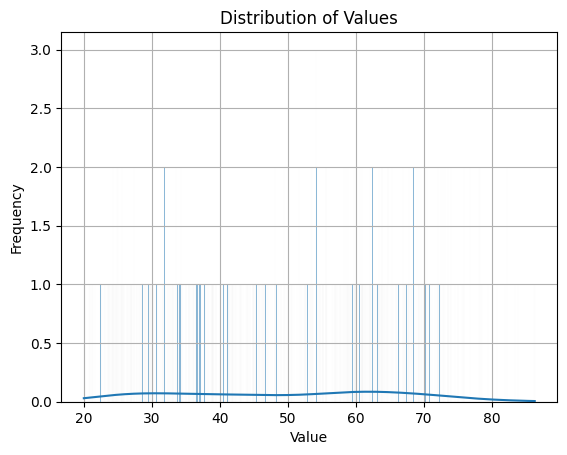

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example list
values = list(df['AGE'])

# Seaborn histogram with KDE
sns.histplot(values, kde=True, bins=10000)
plt.title("Distribution of Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [45]:
ImageVolume, age = ds[0]

In [46]:
age

58.65845311430527

In [47]:
ImageVolume.shape

(128, 128, 128)

(128, 128, 128)


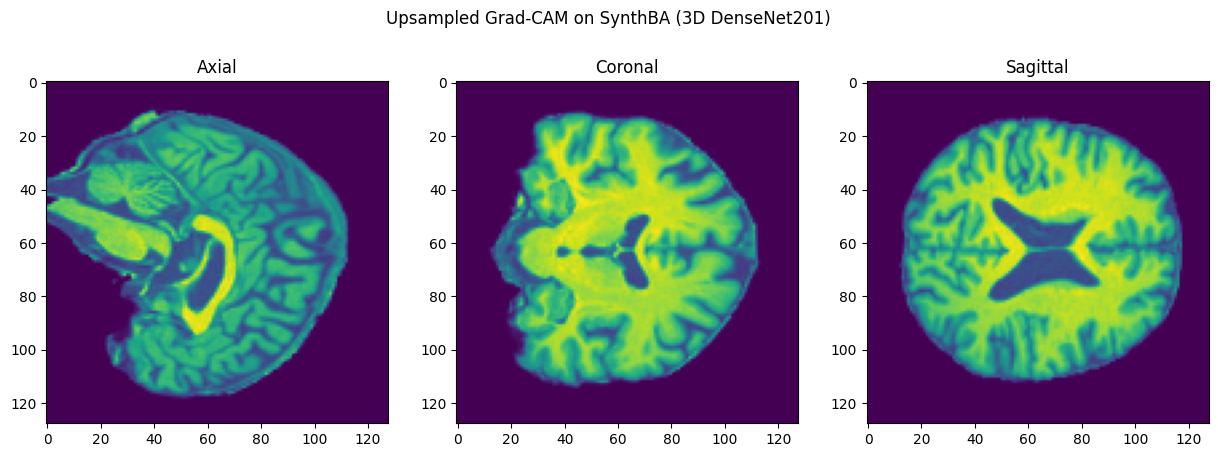

In [48]:
import matplotlib.pyplot as plt

# raw_img: already shape (D, H, W)
attr_map = ImageVolume
print(attr_map.shape)

# Get center slices
z, y, x = [s // 2 for s in attr_map.shape]

import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(attr_map[z])
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(attr_map[:, y, :])
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(attr_map[:, :, x])
plt.title("Sagittal")

plt.suptitle("Upsampled Grad-CAM on SynthBA (3D DenseNet201)")
plt.show()


In [49]:
x, y, z

(64, 64, 64)

(128, 128, 128)


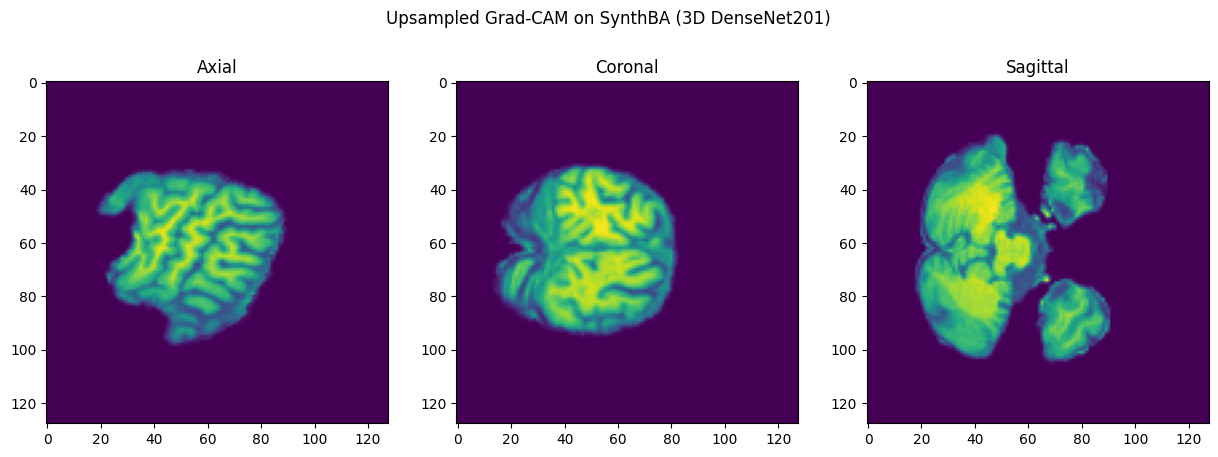

In [50]:
import matplotlib.pyplot as plt

# raw_img: already shape (D, H, W)
attr_map = ImageVolume
print(attr_map.shape)

# Get center slices
z, y, x = [s // 2 for s in attr_map.shape]
x = 100
y = 100
z = 100

x = 20
y = 20
z = 20


import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(attr_map[z])
plt.title("Axial")

plt.subplot(1,3,2)
plt.imshow(attr_map[:, y, :])
plt.title("Coronal")

plt.subplot(1,3,3)
plt.imshow(attr_map[:, :, x])
plt.title("Sagittal")

plt.suptitle("Upsampled Grad-CAM on SynthBA (3D DenseNet201)")
plt.show()